In [42]:
pip install matplotlib seaborn pandas kagglehub

Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import kagglehub

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
import cv2
import numpy as np

In [44]:
# Download latest version
path = kagglehub.dataset_download("yuzheguocs/ldxray")

print("Path to dataset files:", path)

Path to dataset files: /home/rafihaqul/.cache/kagglehub/datasets/yuzheguocs/ldxray/versions/3


In [45]:
train_annotations_path = path + '/train.json'
test_annotations_path = path + '/test.json'
# Load file JSON
with open(train_annotations_path, 'r') as f:
    data_train = json.load(f)

with open(test_annotations_path, 'r') as f:
    data_test = json.load(f)

In [46]:
pd.json_normalize(data_train).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   licenses           1 non-null      object 
 1   images             1 non-null      object 
 2   annotations        1 non-null      object 
 3   categories         1 non-null      object 
 4   info.year          1 non-null      int64  
 5   info.version       1 non-null      float64
 6   info.description   1 non-null      object 
 7   info.contributor   0 non-null      object 
 8   info.url           0 non-null      object 
 9   info.date_created  1 non-null      object 
dtypes: float64(1), int64(1), object(8)
memory usage: 208.0+ bytes


In [47]:
jumlah_data_gambar_train = pd.json_normalize(data_train['images']).shape[0]
jumlah_data_gambar_test = pd.json_normalize(data_test['images']).shape[0]
print("Jumlah data gambar train:", jumlah_data_gambar_train)
print("Jumlah data gambar test:", jumlah_data_gambar_test)
print("persentasi perbandingan data gambar train dan test:" + str(100 * jumlah_data_gambar_train / (jumlah_data_gambar_train + jumlah_data_gambar_test)) + "% : " + str(100 * jumlah_data_gambar_test / (jumlah_data_gambar_train + jumlah_data_gambar_test)) + "%")

Jumlah data gambar train: 110148
Jumlah data gambar test: 36849
persentasi perbandingan data gambar train dan test:74.93214147227495% : 25.067858527725054%


In [48]:
print("------------IMAGES------------")
display(pd.json_normalize(data_train['images']).head(5), 
        pd.json_normalize(data_train['images']).info())

print("------------CATEGORIES------------")
display(pd.json_normalize(data_train['categories']).head(5), 
        pd.json_normalize(data_train['categories']).info())

print("------------ANNOTATIONS------------")
display(pd.json_normalize(data_train['annotations']).head(5), 
        pd.json_normalize(data_train['annotations']).info())

------------IMAGES------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110148 entries, 0 to 110147
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             110148 non-null  int64 
 1   width          110148 non-null  int64 
 2   height         110148 non-null  int64 
 3   file_name      110148 non-null  object
 4   license        110148 non-null  int64 
 5   flickr_url     0 non-null       object
 6   coco_url       0 non-null       object
 7   date_captured  110148 non-null  object
dtypes: int64(4), object(4)
memory usage: 6.7+ MB


,id,width,height,file_name,license,flickr_url,coco_url,date_captured
0,1,548,1040,000000.jpg,1,None,None,2023-12
1,2,472,1040,000001.jpg,1,None,None,2023-12
2,3,492,1040,000002.jpg,1,None,None,2023-12
3,4,440,1040,000003.jpg,1,None,None,2023-12
4,5,444,1040,000004.jpg,1,None,None,2023-12


None

------------CATEGORIES------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             12 non-null     int64 
 1   name           12 non-null     object
 2   supercategory  12 non-null     object
dtypes: int64(1), object(2)
memory usage: 416.0+ bytes


,id,name,supercategory
0,1,Mobile_Phone,Mobile_Phone
1,2,Orange_Liquid,Orange_Liquid
2,3,Charger_Without_Cell,Charger_Without_Cell
3,4,Laptop,Laptop
4,5,Green_Liquid,Green_Liquid


None

------------ANNOTATIONS------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265331 entries, 0 to 265330
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            265331 non-null  int64 
 1   image_id      265331 non-null  int64 
 2   category_id   265331 non-null  int64 
 3   segmentation  265331 non-null  object
 4   area          265331 non-null  int64 
 5   bbox          265331 non-null  object
 6   iscrowd       265331 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 14.2+ MB


,id,image_id,category_id,segmentation,area,bbox,iscrowd
0,1,1,4,"[[116, 400, 116, 834, 462, 834, 462, 400]]",150164,"[116, 400, 346, 434]",0
1,2,2,4,"[[102, 378, 102, 802, 421, 802, 421, 378]]",135256,"[102, 378, 319, 424]",0
2,3,3,4,"[[124, 395, 124, 792, 424, 792, 424, 395]]",119100,"[124, 395, 300, 397]",0
3,4,4,1,"[[101, 736, 101, 866, 345, 866, 345, 736]]",31720,"[101, 736, 244, 130]",0
4,5,5,4,"[[42, 350, 42, 838, 400, 838, 400, 350]]",174704,"[42, 350, 358, 488]",0


None

name                     
Mobile_Phone                 115016
Orange_Liquid                 33691
Charger_Without_Cell          30222
Laptop                        28832
Green_Liquid                  20199
Charger_With_Cell             18471
Tablet                        12094
Blue_Liquid                    3138
Cylindrical_Orange_Liquid      1357
Nonmetallic_Lighter             981
Umbrella                        683
Cylindrical_Green_Liquid        647
Name: count, dtype: int64

name                     
Mobile_Phone                 37993
Orange_Liquid                11357
Charger_Without_Cell         10049
Laptop                        9484
Green_Liquid                  6856
Charger_With_Cell             6200
Tablet                        4083
Blue_Liquid                   1079
Cylindrical_Orange_Liquid      445
Nonmetallic_Lighter            347
Cylindrical_Green_Liquid       226
Umbrella                       196
Name: count, dtype: int64

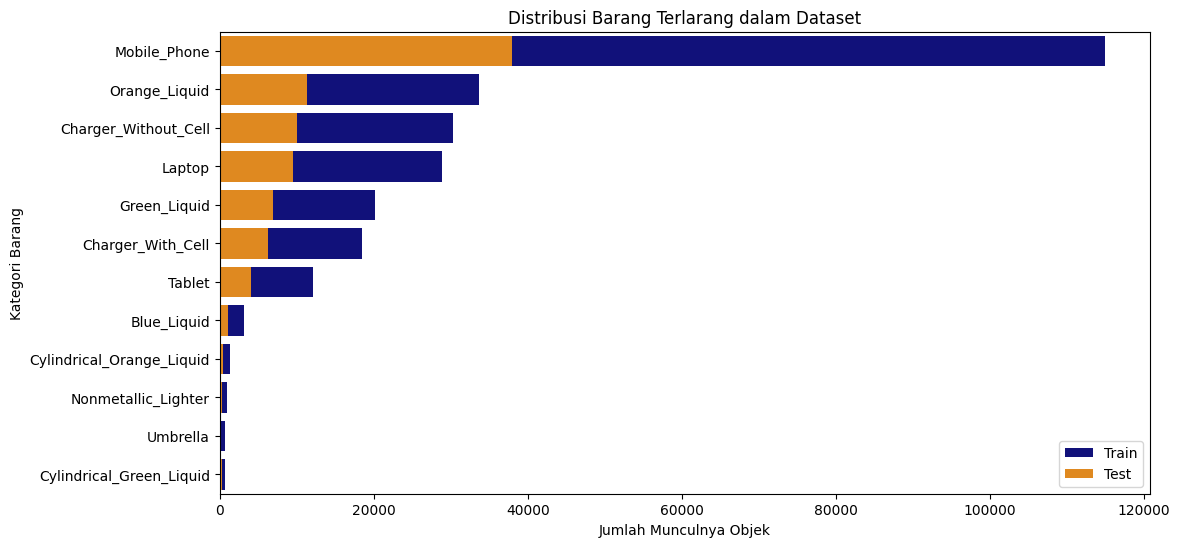

In [49]:
# Buat DataFrame untuk masing-masing bagian
df_train_annotations = pd.DataFrame(data_train['annotations'])
df_train_categories = pd.DataFrame(data_train['categories'])

df_test_annotations = pd.DataFrame(data_test['annotations'])
df_test_categories = pd.DataFrame(data_test['categories'])

# Gabungkan data untuk mendapatkan nama kategori di setiap anotasi
df_train_merged = df_train_annotations.merge(df_train_categories, left_on='category_id', right_on='id')
df_test_merged = df_test_annotations.merge(df_test_categories, left_on='category_id', right_on='id')

display(df_train_merged[['name']].value_counts(), df_test_merged[['name']].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(data=df_train_merged, y='name', order=df_train_merged['name'].value_counts().index, color='darkblue')
sns.countplot(data=df_test_merged, y='name', order=df_test_merged['name'].value_counts().index, color='darkorange')
plt.legend(['Train', 'Test'], loc='lower right')
plt.title('Distribusi Barang Terlarang dalam Dataset')
plt.xlabel('Jumlah Munculnya Objek')
plt.ylabel('Kategori Barang')
plt.show()

In [50]:
display(pd.json_normalize(data_train['categories'])['name'].unique())
display(pd.json_normalize(data_train['categories'])['supercategory'].unique())
print(
    'Categories and Supercategories are the same:', 
    list(pd.json_normalize(data_train['categories'])['name'].unique()) == list(pd.json_normalize(data_train['categories'])['supercategory'].unique())
    )
display(pd.json_normalize(data_train['annotations']).describe())

array(['Mobile_Phone', 'Orange_Liquid', 'Charger_Without_Cell', 'Laptop',
       'Green_Liquid', 'Charger_With_Cell', 'Tablet', 'Blue_Liquid',
       'Cylindrical_Orange_Liquid', 'Nonmetallic_Lighter', 'Umbrella',
       'Cylindrical_Green_Liquid'], dtype=object)

array(['Mobile_Phone', 'Orange_Liquid', 'Charger_Without_Cell', 'Laptop',
       'Green_Liquid', 'Charger_With_Cell', 'Tablet', 'Blue_Liquid',
       'Cylindrical_Orange_Liquid', 'Nonmetallic_Lighter', 'Umbrella',
       'Cylindrical_Green_Liquid'], dtype=object)

Categories and Supercategories are the same: True


,id,image_id,category_id,area,iscrowd
count,265331.000000,265331.000000,265331.000000,265331.000000,265331.0
mean,132666.000000,57447.563123,2.816388,31417.496033,0.0
std,76594.606475,30662.516792,2.149284,34693.701721,0.0
min,1.000000,1.000000,1.000000,0.000000,0.0
25%,66333.500000,31423.500000,1.000000,13588.000000,0.0
50%,132666.000000,57740.000000,2.000000,19261.000000,0.0
75%,198998.500000,84494.500000,4.000000,28200.000000,0.0
max,265331.000000,110148.000000,12.000000,385792.000000,0.0


# HASIL ERD
Struktur Direktori Dataset disusun dengan format berikut:
```bash
.
├── dataset
│   ├── test_A   # 36.849 gambar (.jpg) tampak atas
│   ├── test_B   # 36.849 gambar (.jpg) tampak samping
│   ├── train_A  # 110.148 gambar (.jpg) tampak atas
│   └── train_B  # 110.148 gambar (.jpg) tampak samping
├── test.json
└── train.json
```

Struktur file `.json` mengikuti format relasional seperti berikut:
```bash
+-----------------------+      +-----------------------+      +-----------------------+
|        IMAGES         |      |      ANNOTATIONS      |      |      CATEGORIES       |
+-----------------------+      +-----------------------+      +-----------------------+
| PK | id               |<--+  | PK | id               |  +-->| PK | id               |
|    | width            |   +--| FK | image_id         |  |   |    | name             |
|    | height           |      | FK | category_id      |--+   |    | supercategory    |
|    | file_name        |      |    | segmentation     |      +-----------------------+
|    | license          |      |    | area             | 
|    | flickr_url       |      |    | bbox             | 
|    | coco_url         |      |    | iscrowd          | 
|    | date_captured    |      +-----------------------+ 
+-----------------------+
```

>Penjelasan Singkat
>* **IMAGES** → menyimpan informasi gambar
>* **ANNOTATIONS** → menyimpan label/objek pada gambar
>* **CATEGORIES** → daftar kelas/label objek

>Relasi:
>* `image_id` → menghubungkan anotasi ke gambar
>* `category_id` → menghubungkan anotasi ke kategori

---

## Preprocessing plan
Ubah bentuk dataset menjadi seperti contoh berikut:
```bash
datasets
├── images
│   ├── test
│   │   ├── name1.jpg
│   │   ├── name2.jpg
│   │   └── ...
│   ├── train
│   │   ├── name1.jpg
│   │   ├── name2.jpg
│   │   └── ...
│   └── val
│       ├── name1.jpg
│       ├── name2.jpg
│       └── ...
└── labels
    ├── test
    │   ├── name1.txt >> id_cat bbox
    │   ├── name2.txt >> id_cat bbox
    │   └── ...
    ├── train
    │   ├── name1.txt >> id_cat bbox
    │   ├── name2.txt >> id_cat bbox
    │   └── ...
    └── val
        ├── name1.txt >> id_cat bbox
        ├── name2.txt >> id_cat bbox
        └── ...

data.yaml >>    train: dataset/images/train
                val: dataset/images/val
                test : dataset/images/test

                nc: 2
                names: ["Laptop", "Mobile_Phone", ...]
```

In [51]:
globals().clear()